# SINDy with control input: a first-order forced system

**Goal.** Check that SINDy can recover a simple linear system with a known, measured input $u(t)$:

$$\dot v = -c\,v + u, \qquad c > 0 .$$

This is the velocity of a body with linear drag (or an RC circuit / first-order lag) driven by a force $u$. Despite the file name, it is a *first-order* system, not an oscillator — there is no restoring term, so $v$ relaxes towards $u/c$ rather than oscillating.

**What the notebook shows**
1. Data is generated *exactly* (no integration error) using a zero-order hold (ZOH) on $u$.
2. A naive SINDy fit with centered finite differences returns a **biased** input gain ($\approx 0.5$ instead of $1$).
3. The bias comes from how the derivative is estimated relative to the ZOH input, and disappears when the derivative is aligned with the hold intervals (forward difference).

The lesson carries directly over to the thesis setting: in multi-agent telemetry, actions/inputs are typically piecewise constant per simulation step, so *how you estimate $\dot x$ relative to the input timing* matters as much as the library or the optimizer.

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pysindy as ps

## 1. Generating data with a zero-order hold

On an interval $[t_k, t_k+\Delta t)$ where $u = u_k$ is held constant, the ODE has fixed point $v^* = u_k/c$ and the exact solution

$$v_{k+1} = v^* + (v_k - v^*)\,e^{-c\,\Delta t}.$$

Using this update instead of a numerical integrator means the data contains **no discretisation error**, so any error in the identified model must come from the identification pipeline itself.

Note that `n_holds = T/dt`, i.e. a new random input is drawn at *every* sample. The input is therefore close to white noise, which is a rich excitation for identification but, as we will see, is also what makes the derivative estimate sensitive.

In [2]:
dt = 0.01
T = 100
n_holds = int(round(T / dt))   # 10 000 hold intervals: u changes at every sample

np.random.seed(42)
u_values = np.random.normal(0, 1, n_holds)  # fixed once, not resampled

c = 0.1
v0 = 5

v = np.zeros(n_holds + 1)
v[0] = v0

for k in range(n_holds):
    uk = u_values[k]
    v_star = uk / c  # fixed point the state relaxes toward on this interval
    v[k+1] = v_star + (v[k] - v_star) * np.exp(-c * dt)

t = np.arange(n_holds + 1) * dt   # exact multiples of dt, no drift
U = u_values[np.minimum(np.arange(n_holds + 1), n_holds - 1)]  # u held per point, last point reuses final value

In [3]:
v.shape, U.shape, t.shape

((10001,), (10001,), (10001,))

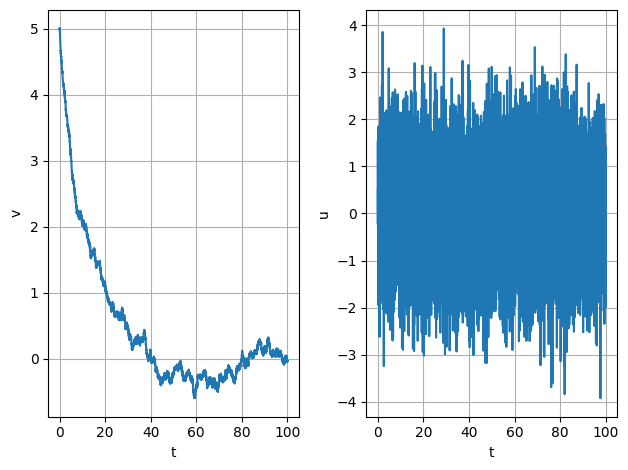

In [4]:
plt.subplot(1, 2, 1)
plt.plot(t, v)
plt.xlabel("t")
plt.ylabel("v")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.step(t, U)
plt.xlabel("t")
plt.ylabel("u")
plt.grid(True)
plt.tight_layout()
plt.show()

**Setup for identification.** $u$ is known/measured, $c>0$ is the unknown parameter SINDy must recover. The true model is

$$\dot v = -0.1\,v + 1.0\,u .$$

## 2. Estimating the derivative

SINDy needs $\dot v$. Two choices are compared below:

| method | formula | time it "belongs to" |
|---|---|---|
| centered difference (PySINDy default) | $\dfrac{v_{k+1}-v_{k-1}}{2\Delta t}$ | spans **two** hold intervals, $u_{k-1}$ and $u_k$ |
| forward difference | $\dfrac{v_{k+1}-v_{k}}{\Delta t}$ | spans exactly **one** hold interval, $u_k$ |

(The right-hand plot previously showed the centered derivative twice; it now shows the forward difference.)

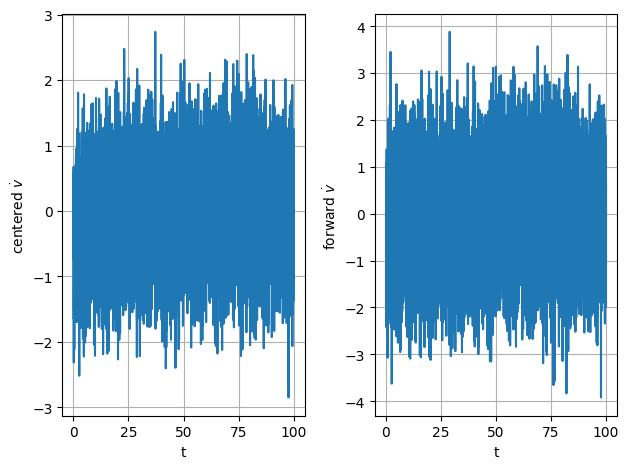

In [5]:
fd = ps.differentiation.FiniteDifference(d=1)
vt_dot = fd(v, t)                     # public call instead of the private fd._differentiate

v_dot_fwd = (v[1:] - v[:-1]) / dt     # length n-1

plt.subplot(1, 2, 1)
plt.plot(t, vt_dot)
plt.xlabel("t")
plt.ylabel("centered $\\dot v$")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t[:-1], v_dot_fwd)
plt.xlabel("t")
plt.ylabel("forward $\\dot v$")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Naive fit: centered differences

Library: $\{1, v, u\}$ (polynomials of degree 1 in the state and input). Optimizer: STLSQ, threshold 0.01.

Reshaping to column vectors and naming the features removes the `AxesWarning` and makes the printout readable.

In [6]:
lib = ps.PolynomialLibrary(degree = 1)
optimizer=ps.STLSQ(threshold = 0.01)

model= ps.SINDy(feature_library=lib,
                      optimizer=optimizer, differentiation_method=ps.FiniteDifference(order=2))

In [7]:
model.fit(v.reshape(-1, 1), t=t, u=U.reshape(-1, 1), feature_names=['v', 'u'])

,optimizer,STLSQ(threshold=0.01)
,feature_library,PolynomialLibrary(degree=1)
,differentiation_method,FiniteDifference()
,degree,1
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.01
,alpha,0.05
,max_iter,20


In [8]:
model.print()

(v)' = -0.092 v +  0.493 u


In [9]:
model.coefficients()

array([[ 0.        , -0.09155332,  0.49261116]])

**Result.** The decay rate is roughly right ($-0.092$ vs. $-0.1$), but the input gain is about **half** of the true value ($0.49$ vs. $1.0$). The model structure is correct; the coefficients are not.

### Why the gain is halved

The centered difference at $t_k$ integrates the dynamics over $[t_{k-1}, t_{k+1}]$, during which the input takes *two* values:

$$\frac{v_{k+1}-v_{k-1}}{2\Delta t} \approx -c\,v_k + \tfrac12 u_{k-1} + \tfrac12 u_k .$$

SINDy regresses this onto $u_k$ only. Because the $u_k$ are i.i.d., $u_{k-1}$ is uncorrelated with $u_k$ and acts as noise, so the fitted gain is $\approx \tfrac12$. The cell below checks this by adding $u_{k-1}$ to a plain least-squares fit: both lagged gains come out at $0.5$, summing to the true gain of $1$.

In [10]:
v_c = (v[2:] - v[:-2]) / (2 * dt)                 # centered derivative at t_1 ... t_{n-1}
Theta = np.column_stack([v[1:-1], U[1:-1], U[:-2]])  # v_k, u_k, u_{k-1}
coef, *_ = np.linalg.lstsq(Theta, v_c, rcond=None)
print(f"-c  = {coef[0]:.4f}   gain(u_k) = {coef[1]:.4f}   gain(u_(k-1)) = {coef[2]:.4f}")

-c  = -0.1000   gain(u_k) = 0.4998   gain(u_(k-1)) = 0.5003


## 4. Fix: forward difference aligned with the hold

Pairing $\dot v_k = (v_{k+1}-v_k)/\Delta t$ with $v_k$ and $u_k$ makes every regression row describe exactly one hold interval. The last sample is dropped because it has no following interval.

The library here is degree 2 ($\{1, v, u, v^2, vu, u^2\}$), so it is also a small test that STLSQ prunes the spurious quadratic terms.

In [11]:
v_dot_fwd = (v[1:] - v[:-1]) / dt   # length n-1, v_dot_fwd[k] uses v[k], v[k+1]
v_trunc   = v[:-1]                  # drop last point — no future interval for it
u_trunc   = U[:-1]                  # aligned: u_trunc[k] is the u held over [t_k, t_k+dt)
t_trunc   = t[:-1]

model_fwd = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=2), optimizer=ps.STLSQ(threshold=0.01))
model_fwd.fit(v_trunc.reshape(-1, 1), t=t_trunc, x_dot=v_dot_fwd.reshape(-1, 1), u=u_trunc.reshape(-1, 1), feature_names=['v', 'u'])
model_fwd.print()

(v)' = -0.100 v +  1.000 u


**Result.** $\dot v = -0.100\,v + 1.000\,u$ — both coefficients recovered, and all quadratic terms pruned.

(The remaining tiny error is the $\mathcal O(c\,\Delta t)$ error of a forward difference against the exact exponential update; it vanishes as $\Delta t \to 0$.)

## Takeaways and possible next steps

- With piecewise-constant inputs, the derivative estimate must be **time-aligned with the input**. Centered differences mix neighbouring inputs; this is a systematic bias, not noise, so more data does not fix it.
- Alternatives that avoid the issue: hold $u$ over many samples (the bias then only appears at switching instants), or use the **discrete-time** SINDy formulation ($x_{k+1} = f(x_k, u_k)$, `ps.SINDy(discrete_time=True)`, Brunton et al. §3.3.1), which needs no derivative at all.
- Natural extensions: add measurement noise to $v$, sweep the SINDy threshold, and validate by simulating the identified model (`model.simulate`) on a *new* input sequence.